# Figure 4 — Where odorants sit in chemical space

Odorants are compared against every other natural product in COCONUT. Both sides are
natural products, so the differences between them are the result rather than a confound.

The short answer: odour chemistry is not a separate island. It is the small, volatile,
nitrogen-free corner of natural-product space, and it comes mostly from plants.

**What you need to run this**

The two small tables this notebook reads are in the repository. The map in panel **a**
also needs the large intermediates, which come from Zenodo:

```bash
python scripts/download_zenodo_data.py --assets chemical_space
```

Nothing here recomputes the analysis. That is `01`–`11`, and `02` needs a GPU —
see [`README.md`](README.md).

In [1]:
import warnings
warnings.filterwarnings("ignore")   # library deprecation notices only; keeps stored output clean
import os, sys
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")   # keep TensorFlow's start-up log out of the output

from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import 11_paper_figures as 11          # the panel functions that draw the published figure

RESULTS = Path("results")

# 11.save() writes the figure to disk and closes it. Here we want it on the page instead,
# so capture the figure object and let the notebook display it.
DRAWN = {}
11.save = lambda figure, name: DRAWN.__setitem__(name, figure)

print("chemical-space results:", RESULTS.resolve().relative_to(Path.cwd().parents[1]))

chemical-space results: Chemicals/results


## The figure

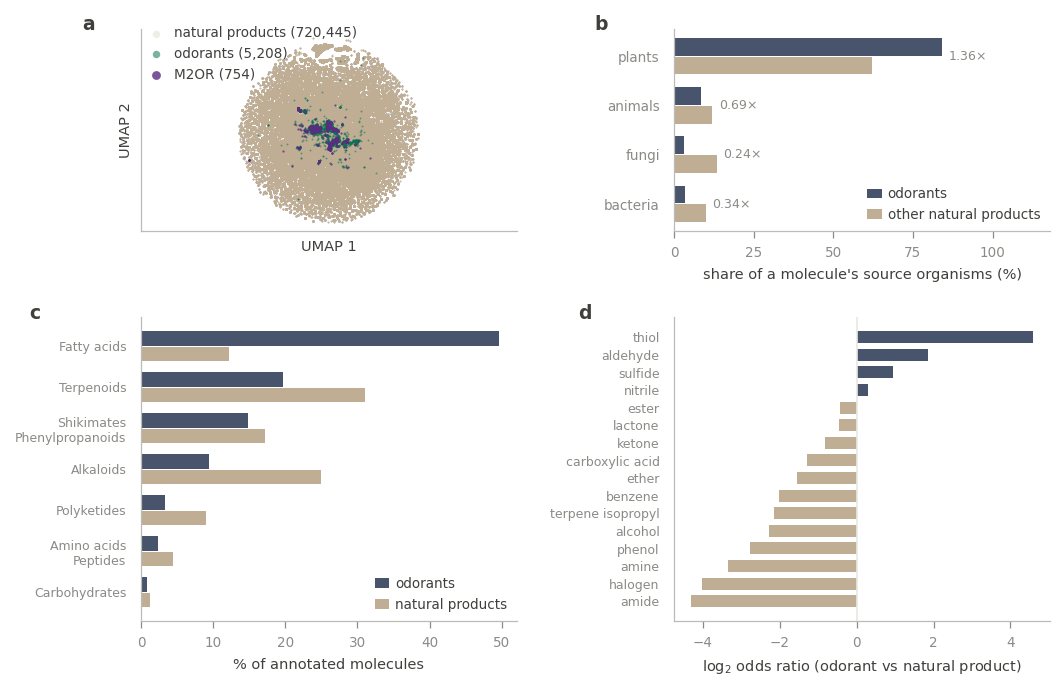

In [2]:
11.figure4()


**Figure 4 | Odorants occupy a plant-derived, volatile corner of natural-product chemical space.**

**a**, 726,407 molecules on a UMAP of their MoLFormer embeddings: 720,445 non-odorant
natural products (sand), 5,208 odorants not in M2OR (green) and 754 M2OR ligands (purple).
Axes are arbitrary. Odorants sit in a compact central region, not off to one side.

**b**, Mean share of a molecule's recorded source organisms falling in each group.
Restricted to the 269,445 molecules with at least one recorded organism.

**c**, Biosynthetic pathway (NPClassifier) as a percentage of annotated molecules.

**d**, Functional-group enrichment as log₂ odds ratio, odorants against other natural
products. Positive means enriched in odorants.

## The numbers behind each panel

Each block below is the table the panel is drawn from, so the figure can be checked
against the values rather than read off the axes.

### a — how tightly do odorants cluster?

In [3]:
# Of a molecule's 50 nearest neighbours in embedding space, what fraction are also odorants?
# Divided by the overall odorant rate, this is an enrichment: 1.0 would mean no clustering.
knn  = pd.read_csv(RESULTS / "knn_enrichment.csv")
null = pd.read_csv(RESULTS / "robust_knn_null.csv")

observed = knn.enrichment.iloc[0]
matched  = null.loc[null.set == "matched_np", "enrichment"].mean()

print(f"odorants                      {observed:5.1f}x more clustered than chance")
print(f"natural products matched to")
print(f"  odorants on size+volatility {matched:5.1f}x")
print(f"                              {'-'*22}")
print(f"ratio, the reportable signal  {observed / matched:5.1f}x")
print()
print("The 46.9x on its own overstates it: molecules matched on size and volatility")
print(f"already cluster at {matched:.1f}x. Neither number should be quoted alone.")

odorants                       46.9x more clustered than chance
natural products matched to
  odorants on size+volatility  18.5x
                              ----------------------
ratio, the reportable signal    2.5x

The 46.9x on its own overstates it: molecules matched on size and volatility
already cluster at 18.5x. Neither number should be quoted alone.


### b — which organisms are odorants recorded from?

In [4]:
king = pd.read_csv(RESULTS / "organism_kingdom_summary.csv")
out = (king[["taxon", "pct_odorant", "pct_background", "odds_ratio", "q"]]
       .rename(columns={"pct_odorant": "% odorant", "pct_background": "% other NP",
                        "odds_ratio": "odds ratio"})
       .sort_values("odds ratio", ascending=False))
print(out.to_string(index=False, float_format=lambda v: f"{v:,.3g}"))

            taxon  % odorant  % other NP  odds ratio         q
     Thermotogati      0.752      0.0411        18.4  5.91e-14
    Viridiplantae       92.6        63.3         7.3 2.72e-203
Methanobacteriati      0.852       0.154        5.57  4.28e-08
   Pseudomonadati       15.6        3.39        5.26 1.21e-107
          Archaea      0.902       0.194        4.69  1.77e-07
        Eukaryota       96.8        87.9        4.15  5.87e-45
          Metazoa       42.8        17.9        3.43 1.67e-144
         Bacteria       26.9        13.6        2.34  3.04e-54
        Bacillati       21.4        11.3        2.15  7.07e-38
            Fungi       29.5        19.3        1.76  1.12e-27
   Thermoproteati     0.0501      0.0411        1.22     0.562


### c — which biosynthetic pathways?

In [5]:
path = pd.read_csv(RESULTS / "pathway_enrichment.csv").sort_values("pct_odorant", ascending=False)
out = (path[["pathway", "pct_odorant", "pct_background", "odds_ratio", "ci_lo", "ci_hi", "q"]]
       .rename(columns={"pct_odorant": "% odorant", "pct_background": "% other NP",
                        "odds_ratio": "odds ratio"}))
print(out.to_string(index=False, float_format=lambda v: f"{v:,.3g}"))
print()
print("Fatty acids dominate: half of all annotated odorants, against an eighth of other")
print("natural products. Carbohydrates is the one pathway that does not differ.")

                        pathway  % odorant  % other NP  odds ratio  ci_lo  ci_hi        q
                    Fatty acids       49.6        12.2        7.08   6.56   7.65        0
                     Terpenoids       19.6        31.1       0.541  0.491  0.596 3.07e-39
Shikimates and Phenylpropanoids       14.8        17.1       0.839  0.754  0.936  0.00157
                      Alkaloids       9.37        24.9       0.312  0.274  0.357 6.12e-90
                    Polyketides       3.38        9.04       0.352  0.286  0.438 1.18e-29
       Amino acids and Peptides       2.42        4.44       0.533  0.419   0.69 1.12e-07
                  Carbohydrates      0.845         1.2       0.701  0.473   1.09    0.104

Fatty acids dominate: half of all annotated odorants, against an eighth of other
natural products. Carbohydrates is the one pathway that does not differ.


### d — which functional groups?

In [6]:
fg = pd.read_csv(RESULTS / "fg_enrichment.csv").sort_values("odds_ratio", ascending=False)
out = (fg[["group", "pct_odorant", "pct_background", "odds_ratio", "ci_lo", "ci_hi", "q"]]
       .rename(columns={"group": "functional group", "pct_odorant": "% odorant",
                        "pct_background": "% other NP", "odds_ratio": "odds ratio"}))
out["functional group"] = out["functional group"].str.replace("fg_", "", regex=False)
print(out.to_string(index=False, float_format=lambda v: f"{v:,.3g}"))
print()
print("Thiol is the most enriched group and amide the most depleted: odour chemistry")
print("carries sulfur and avoids nitrogen.")

 functional group  % odorant  % other NP  odds ratio  ci_lo  ci_hi         q
            thiol       3.37       0.146        23.9   20.6   27.9 8.66e-187
         aldehyde       8.42        2.47        3.62   3.31   3.98 2.28e-118
          sulfide        8.6        4.67        1.92   1.76   2.11  5.03e-38
          nitrile      0.939        0.77        1.22  0.947    1.6     0.137
            ester       33.7        40.6       0.743  0.704  0.784   7.5e-28
          lactone       32.2        39.6       0.726  0.687  0.767  1.24e-31
           ketone       13.9        22.4       0.562  0.523  0.606     3e-60
  carboxylic_acid       5.43        12.3        0.41  0.367  0.459  8.58e-71
            ether       49.3        74.1       0.339  0.322  0.356         0
          benzene       20.4        51.3       0.244  0.229   0.26         0
terpene_isopropyl       52.2        83.1       0.223  0.212  0.235         0
          alcohol       15.6        47.4       0.205  0.191   0.22         0

## Extended Data Figure 7

Supporting detail: the aromatic/aliphatic split, whether receptor class corresponds to any
difference in volatility (it does not), and the source taxa at finer ranks.

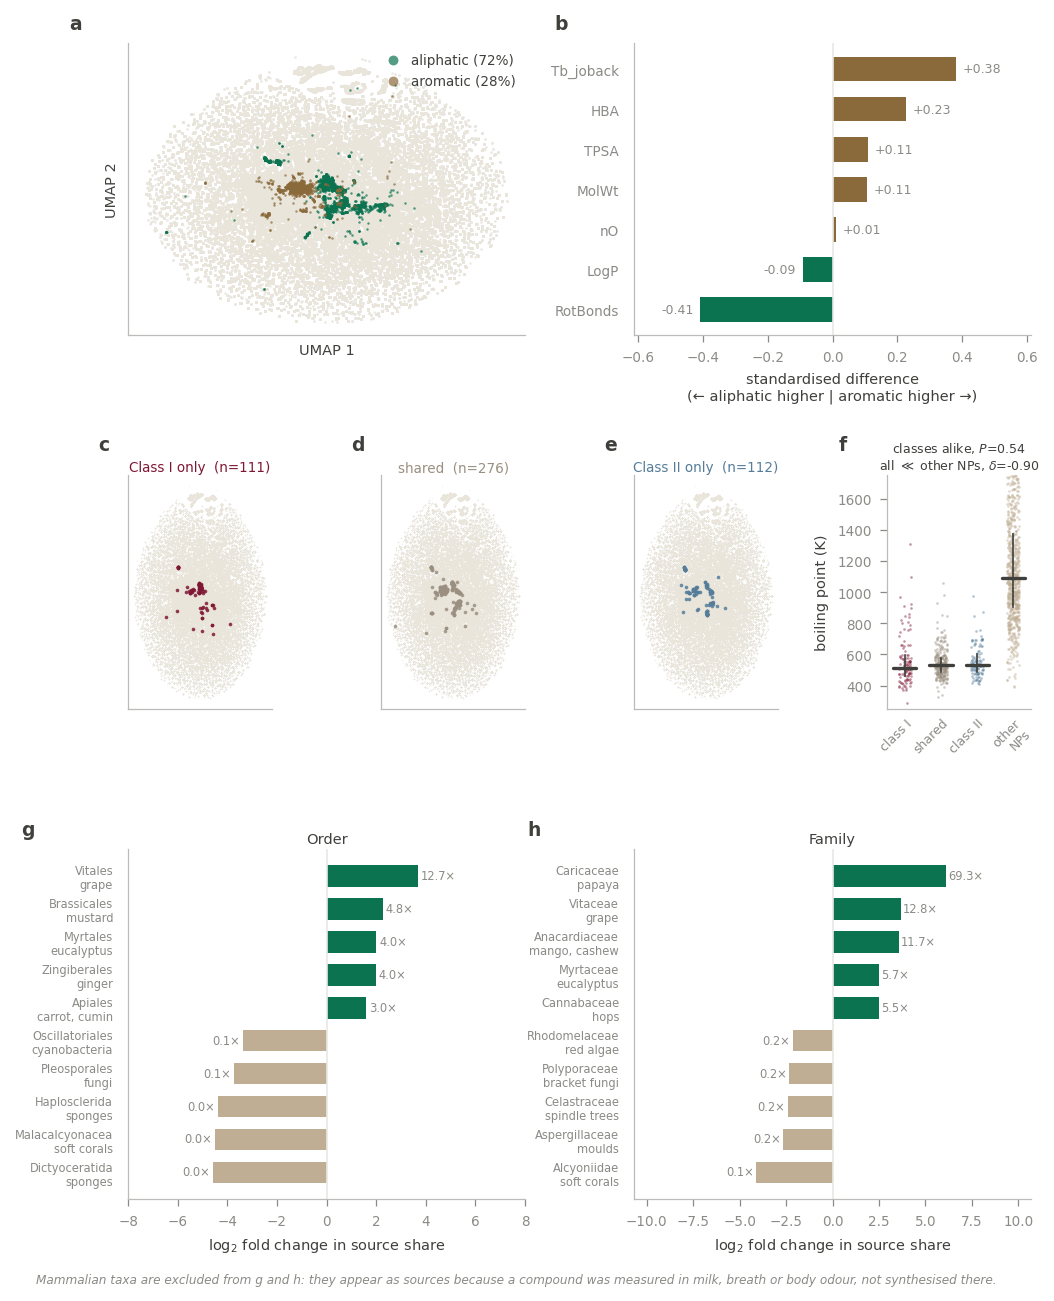

In [7]:
11.supplementary()


**Extended Data Fig. 7 | Structural, receptor-class and taxonomic detail of odorant chemical space.**

**a,b**, Odorants split by whether they carry a benzene ring: 4,281 aliphatic (72%) and
1,681 aromatic (28%). Aromatics boil higher and are less flexible; they differ little in mass.

**c–f**, Molecules read only by class I (n = 111), by both classes (n = 276) and only by
class II (n = 112). All three sit in the same region, and their boiling points are
indistinguishable (Kruskal–Wallis P = 0.54) — while all three differ sharply from other
natural products (Cliff's δ = −0.90). Volatility separates odorants from natural products,
not the receptor classes from each other.

**g,h**, Source-organism enrichment at order and family rank. The enriched taxa are
culinary plant lineages. Mammals are excluded: they appear as "sources" where a compound
was measured in milk, breath or body odour, not synthesised there.

## Regenerating this

The figures above are drawn by [`11_paper_figures.py`](11_paper_figures.py) from the
outputs of the pipeline. To rebuild them as the files that go to the manuscript:

```bash
python Chemicals/11_paper_figures.py            # writes figures/*.svg and *.pdf
```

To redo the analysis from scratch, run `01`–`10` in order. **`02` embeds 730,000
molecules with MolFormer and needs a GPU**; it refuses to run on CPU. See
[`README.md`](README.md).

Three limits worth carrying into any reading of this figure:

1. Joback boiling points are estimates fitted mainly on small molecules. The odorant side
   is sound; absolute volatility claims about the background are not.
2. COCONUT records where people have looked. Plants are over-studied for volatiles, so the
   organism comparison is partly between two literatures.
3. The background is "not on an odorant list", not "verified odourless".